# Fase 4 — Modelado Predictivo del Lead Time Contractual

Estima los dias entre **convocatoria** y **suscripcion** del contrato (`Lead_Time_Total`) para cada item, incluidos los procesos 2024-2025 aun en curso, y publica las predicciones en `bi/Pred_Lead_Time.parquet` para la Vista Tactica de Power BI.

**Prerrequisito:** haber ejecutado `python main.py gold` (genera los 7 Parquet en `bi/`).

Correcciones aplicadas (ver CHANGELOG 9.3): Lead Times negativos -> `NaN`, objetivo en escala **log1p** (`TransformedTargetRegressor`) para predicciones siempre >= 0, `ID_Registro` como clave estable y XGBoost `n_jobs=1` (reproducible entre entornos).

In [1]:
import pandas as pd, numpy as np, joblib, warnings
from pathlib import Path
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb

warnings.filterwarnings('ignore')
BI_DIR  = Path('../bi')
MDL_DIR = Path('models'); MDL_DIR.mkdir(exist_ok=True)

CAT = ['Red_Asistencial', 'Categoria_Proceso', 'Especialidad_Autorizada',
       'Tipo_Red', 'Metodo_Clasificacion']
NUM = ['Monto_Adjudicado_Soles', 'Anio_Fiscal', 'Mes_Convocatoria', 'retraso_historico_red']
BIN = ['Flag_Contratacion_Directa', 'Flag_Tiene_Adenda']
TARGET = 'Lead_Time_Total'

In [2]:
fact    = pd.read_parquet(BI_DIR / 'Fact_Ordenes_Y_Contratos.parquet')
entidad = pd.read_parquet(BI_DIR / 'Dim_Entidad_Compradora.parquet')
med     = pd.read_parquet(BI_DIR / 'Dim_Medicamento.parquet')
tipo    = pd.read_parquet(BI_DIR / 'Dim_Tipo_Proceso.parquet')

df = (fact
  .merge(entidad[['SK_Entidad', 'Red_Asistencial', 'Tipo_Red']],
         left_on='FK_Entidad', right_on='SK_Entidad', how='left')
  .merge(med[['SK_Medicamento', 'Especialidad_Autorizada', 'Metodo_Clasificacion']],
         left_on='FK_Medicamento', right_on='SK_Medicamento', how='left')
  .merge(tipo[['SK_Tipo_Proceso', 'Categoria_Proceso']],
         left_on='FK_Tipo_Proceso', right_on='SK_Tipo_Proceso', how='left'))
print('Fact:', len(fact), '| df tras joins:', len(df))

Fact: 9292 | df tras joins: 9292


In [3]:
to_dt = lambda c: pd.to_datetime(df[c], errors='coerce')
df['Lead_Time_Total']  = (to_dt('Fecha_Suscripcion') - to_dt('Fecha_Convocatoria')).dt.days
df['Lead_Time_Comite'] = (to_dt('Fecha_Buena_Pro')   - to_dt('Fecha_Convocatoria')).dt.days

# CORRECCION 9.3: fechas inconsistentes (suscripcion antes que convocatoria) -> NaN,
# nunca Lead Times negativos.
df.loc[df['Lead_Time_Total']  < 0, 'Lead_Time_Total']  = np.nan
df.loc[df['Lead_Time_Comite'] < 0, 'Lead_Time_Comite'] = np.nan

df['Mes_Convocatoria']  = to_dt('Fecha_Convocatoria').dt.month.fillna(0).astype(int)
df['Flag_Tiene_Adenda'] = (df['Monto_Adicional'].fillna(0) > 0).astype(int)

# Historial de retraso del comite por Red (imputado con la media global).
hist = df.groupby('Red_Asistencial')['Lead_Time_Comite'].mean().rename('retraso_historico_red')
df = df.merge(hist, on='Red_Asistencial', how='left')
df['retraso_historico_red'] = df['retraso_historico_red'].fillna(df['Lead_Time_Comite'].mean())

for c in CAT: df[c] = df[c].fillna('DESCONOCIDO')
for c in BIN: df[c] = df[c].fillna(0)

df_ml = df[df['Lead_Time_Total'].notna()].copy()   # >= 0 garantizado (negativos ya son NaN)
print(f'Registros para ML: {len(df_ml)} / {len(df)} '
      f'(actuals validos, sin negativos)')

Registros para ML: 5917 / 9292 (actuals validos, sin negativos)


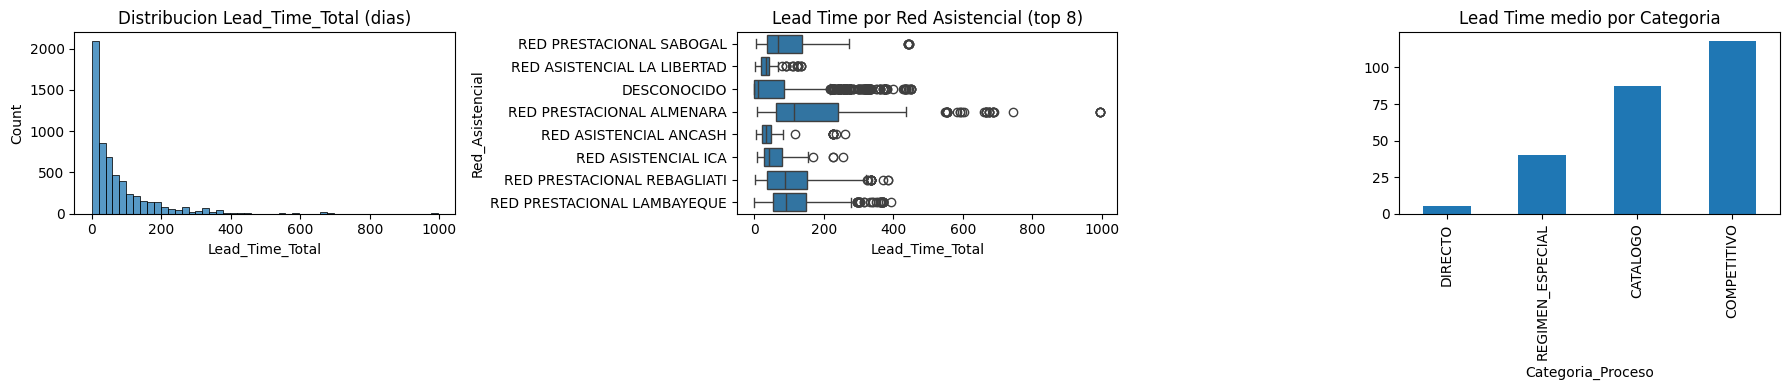

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df_ml['Lead_Time_Total'], bins=50, ax=ax[0])
ax[0].set_title('Distribucion Lead_Time_Total (dias)')
top = df_ml['Red_Asistencial'].value_counts().head(8).index
sns.boxplot(data=df_ml[df_ml['Red_Asistencial'].isin(top)],
            x='Lead_Time_Total', y='Red_Asistencial', ax=ax[1])
ax[1].set_title('Lead Time por Red Asistencial (top 8)')
(df_ml.groupby('Categoria_Proceso')['Lead_Time_Total'].mean()
      .sort_values().plot.bar(ax=ax[2], title='Lead Time medio por Categoria'))
plt.tight_layout(); plt.show()

In [5]:
X = df_ml[CAT + NUM + BIN].copy()
y = df_ml[TARGET].astype(float)

pre = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT),
    ('num', StandardScaler(), NUM),
    ('bin', 'passthrough', BIN),
])
print('X:', X.shape, '| features:', CAT + NUM + BIN)

X: (5917, 11) | features: ['Red_Asistencial', 'Categoria_Proceso', 'Especialidad_Autorizada', 'Tipo_Red', 'Metodo_Clasificacion', 'Monto_Adjudicado_Soles', 'Anio_Fiscal', 'Mes_Convocatoria', 'retraso_historico_red', 'Flag_Contratacion_Directa', 'Flag_Tiene_Adenda']


In [6]:
strat_labels = LabelEncoder().fit_transform(df_ml['Red_Asistencial'])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(skf.split(X, strat_labels))
print(f'{len(cv_splits)} folds estratificados por Red Asistencial')

5 folds estratificados por Red Asistencial


In [7]:
# Objetivo en escala log1p -> predicciones siempre >= 0 (CORRECCION 9.3).
# n_jobs=1 -> reproducible entre host y worker Docker.
xgb_reg = TransformedTargetRegressor(
    regressor=xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1),
    func=np.log1p, inverse_func=np.expm1)
pipe_xgb = Pipeline([('pre', pre), ('xgb', xgb_reg)])

rmse_xgb = []
for tr, val in cv_splits:
    pipe_xgb.fit(X.iloc[tr], y.iloc[tr])
    rmse_xgb.append(root_mean_squared_error(y.iloc[val], pipe_xgb.predict(X.iloc[val])))
print(f'XGBoost (log1p)  CV RMSE: {np.mean(rmse_xgb):.2f} +/- {np.std(rmse_xgb):.2f} dias')

XGBoost (log1p)  CV RMSE: 56.61 +/- 5.29 dias


In [8]:
rf_reg = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1),
    func=np.log1p, inverse_func=np.expm1)
pipe_rf = Pipeline([('pre', pre), ('rf', rf_reg)])

rmse_rf = []
for tr, val in cv_splits:
    pipe_rf.fit(X.iloc[tr], y.iloc[tr])
    rmse_rf.append(root_mean_squared_error(y.iloc[val], pipe_rf.predict(X.iloc[val])))
print(f'Random Forest (log1p) CV RMSE: {np.mean(rmse_rf):.2f} +/- {np.std(rmse_rf):.2f} dias')

Random Forest (log1p) CV RMSE: 63.40 +/- 6.43 dias


In [9]:
resultados = pd.DataFrame({
    'Modelo': ['XGBoost', 'Random Forest'],
    'RMSE_Mean': [np.mean(rmse_xgb), np.mean(rmse_rf)],
    'RMSE_Std':  [np.std(rmse_xgb),  np.std(rmse_rf)],
}).sort_values('RMSE_Mean')
print(resultados.to_string(index=False))

best_pipe = pipe_xgb if np.mean(rmse_xgb) <= np.mean(rmse_rf) else pipe_rf
best_name = 'XGBoost' if best_pipe is pipe_xgb else 'Random Forest'
best_step = 'xgb' if best_pipe is pipe_xgb else 'rf'
best_pipe.fit(X, y)   # reentrenar sobre datos completos
print(f'\nModelo seleccionado: {best_name}')

       Modelo  RMSE_Mean  RMSE_Std
      XGBoost  56.609781  5.294441
Random Forest  63.398598  6.429936



Modelo seleccionado: XGBoost


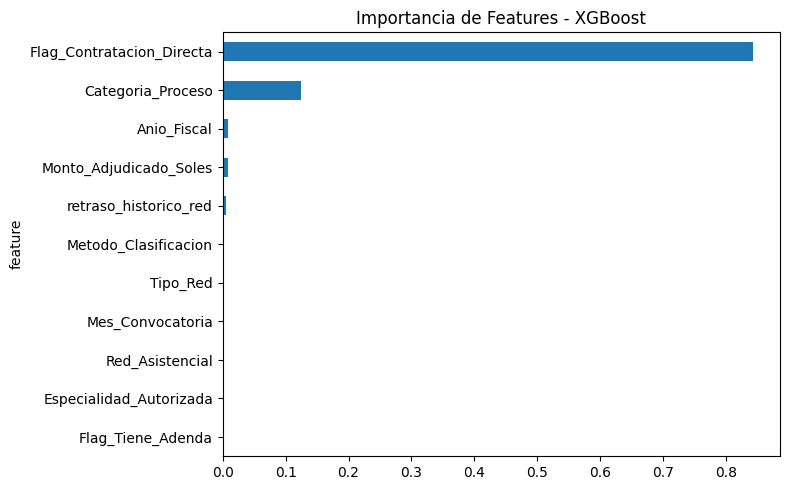

In [10]:
reg = best_pipe.named_steps[best_step].regressor_
importances = reg.feature_importances_
(pd.DataFrame({'feature': CAT + NUM + BIN, 'importance': importances})
   .sort_values('importance')
   .plot.barh(x='feature', y='importance', figsize=(8, 5), legend=False,
              title='Importancia de Features - ' + best_name))
plt.tight_layout(); plt.show()

In [11]:
# Predice sobre TODOS los registros (incluidos los sin fecha de suscripcion).
X_all = df[CAT + NUM + BIN]
pred_all = np.clip(best_pipe.predict(X_all), 0, None).round(1)

pred_table = pd.DataFrame({
    'ID_Registro':        np.arange(len(df), dtype=int),
    'Codigo_Convocatoria': df['Codigo_Convocatoria'].to_numpy(),
    'N_Item':              df['N_Item'].to_numpy(),
    'Anio_Fiscal':         df['Anio_Fiscal'].astype(int).to_numpy(),
    'Red_Asistencial':     df['Red_Asistencial'].to_numpy(),
    'Categoria_Proceso':   df['Categoria_Proceso'].to_numpy(),
    'Lead_Time_Actual':    df['Lead_Time_Total'].to_numpy(),
    'Lead_Time_Predicho':  pred_all,
})
pred_table['Residual'] = np.where(
    pred_table['Lead_Time_Actual'].notna(),
    pred_table['Lead_Time_Actual'] - pred_table['Lead_Time_Predicho'],
    np.nan)

out = BI_DIR / 'Pred_Lead_Time.parquet'
pred_table.to_parquet(out, index=False)
print(f'Exportado: {out}  ({len(pred_table)} registros)')
v = pred_table['Lead_Time_Actual'].notna()
print(f"Actuals validos: {int(v.sum())} | solo prediccion: {int((~v).sum())}")
print(f"MAE: {pred_table.loc[v, 'Residual'].abs().mean():.1f} dias")
print(pred_table.groupby('Categoria_Proceso')['Lead_Time_Predicho'].mean().round(1).to_string())

Exportado: ..\bi\Pred_Lead_Time.parquet  (9292 registros)
Actuals validos: 5917 | solo prediccion: 3375
MAE: 15.6 dias
Categoria_Proceso
CATALOGO             75.199997
COMPETITIVO         104.900002
DIRECTO               5.400000
REGIMEN_ESPECIAL     20.200001


In [12]:
joblib.dump(best_pipe, MDL_DIR / 'best_model.joblib')
print('Guardado: mlpredicts/models/best_model.joblib')
print("Carga: model = joblib.load('models/best_model.joblib')")
print('Uso:   pred  = model.predict(X_new)  # columnas CAT+NUM+BIN')

Guardado: mlpredicts/models/best_model.joblib


Carga: model = joblib.load('models/best_model.joblib')
Uso:   pred  = model.predict(X_new)  # columnas CAT+NUM+BIN
